# ✋ Task-04: Hand Gesture Recognition

**Internship:** Prodigy Infotech  
**Task:** Develop a hand gesture recognition model that can accurately identify and classify different hand gestures from image data, enabling intuitive human-computer interaction.  
**Dataset:** [LeapGestRecog – Kaggle](https://www.kaggle.com/datasets/gti-upm/leapgestrecog)

---

## 📌 Dataset Info
- **20,000 infrared images** captured by Leap Motion sensor
- **10 gesture classes:** palm, l, fist, fist_moved, thumb, index, ok, palm_moved, c, down
- **10 subjects** (5 male, 5 female)
- **200 images per gesture per subject**

## 🔁 Workflow
1. Import libraries
2. Load & explore dataset
3. Preprocess & extract features (HOG)
4. Train/test split
5. Train Random Forest + SVM models
6. Evaluate & compare models
7. Visualise results
8. Predict on a single image

---
## Step 1 — Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Step 2 — Configuration

**Expected folder structure after extracting the zip:**
```
leapgestrecog/
└── leapGestRecog/
    ├── 00/
    │   ├── 01_palm/        ← gesture folders
    │   ├── 02_l/
    │   ├── 03_fist/
    │   └── ... (10 gestures)
    ├── 01/                 ← subject folders (00 to 09)
    ├── 02/
    └── ... (10 subjects)
```

> ⚠️ Update `DATASET_PATH` to point to the `leapGestRecog` folder on your computer.

In [2]:
# ── UPDATE THIS PATH ──
DATASET_PATH = 'leapGestRecog'   # path to leapGestRecog folder

IMG_SIZE    = 64      # resize images to 64x64
MAX_IMAGES  = 200     # images per gesture class (max 2000, use 200 for speed)
RANDOM_SEED = 42

print(f'Dataset path : {DATASET_PATH}')
print(f'Image size   : {IMG_SIZE}x{IMG_SIZE}')
print(f'Max images   : {MAX_IMAGES} per class')

Dataset path : leapGestRecog
Image size   : 64x64
Max images   : 200 per class


---
## Step 3 — Explore Dataset Structure

Let's first understand the folder structure and list all gesture classes.

In [4]:
import kagglehub
import os

# Auto-find the downloaded dataset path
base_path = r'C:\Users\USER\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1'

DATASET_PATH = None
for root, dirs, files in os.walk(base_path):
    if 'leapGestRecog' in dirs:
        DATASET_PATH = os.path.join(root, 'leapGestRecog')
        break

if DATASET_PATH is None:
    print('❌ leapGestRecog not found, searching...')
    for root, dirs, files in os.walk(base_path):
        print(root)
else:
    print(f'✅ Found: {DATASET_PATH}')
    print(f'Contents: {os.listdir(DATASET_PATH)}')

IMG_SIZE    = 64
MAX_IMAGES  = 200
RANDOM_SEED = 42

✅ Found: C:\Users\USER\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1\leapGestRecog
Contents: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', 'leapGestRecog']


In [5]:
import kagglehub
import os

base_path = r'C:\Users\USER\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1\leapGestRecog'

# Check if subject folders (00-09) are directly here or inside nested folder
contents = os.listdir(base_path)
print(f'Contents: {contents}')

# If '00' folder exists directly, use this path
if '00' in contents:
    DATASET_PATH = base_path
else:
    # Use the nested leapGestRecog folder
    DATASET_PATH = os.path.join(base_path, 'leapGestRecog')

print(f'✅ DATASET_PATH set to: {DATASET_PATH}')
print(f'Contents: {os.listdir(DATASET_PATH)}')

IMG_SIZE    = 64
MAX_IMAGES  = 200
RANDOM_SEED = 42

Contents: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', 'leapGestRecog']
✅ DATASET_PATH set to: C:\Users\USER\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1\leapGestRecog
Contents: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', 'leapGestRecog']


---
## Step 4 — Load & Preprocess Images

We loop through all subject folders and gesture folders to load images.

Each image is:
1. Read in grayscale (images are already infrared/grayscale)
2. Resized to 64×64
3. Stored with its gesture label

> ⏳ Loading may take 1-2 minutes for all 20,000 images.

In [6]:
images = []
labels = []

subjects = sorted(os.listdir(DATASET_PATH))

# Count per class to respect MAX_IMAGES limit
class_counts = {}

for subject in subjects:
    subject_path = os.path.join(DATASET_PATH, subject)
    if not os.path.isdir(subject_path):
        continue

    gesture_folders = sorted(os.listdir(subject_path))

    for gesture_folder in gesture_folders:
        gesture_path = os.path.join(subject_path, gesture_folder)
        if not os.path.isdir(gesture_path):
            continue

        # Extract clean gesture name (e.g. '01_palm' → 'palm')
        gesture_name = '_'.join(gesture_folder.split('_')[1:])

        if gesture_name not in class_counts:
            class_counts[gesture_name] = 0

        # Skip if already loaded enough for this class
        if class_counts[gesture_name] >= MAX_IMAGES:
            continue

        all_files = [
            f for f in os.listdir(gesture_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ]

        for fname in all_files:
            if class_counts[gesture_name] >= MAX_IMAGES:
                break

            img = cv2.imread(os.path.join(gesture_path, fname), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img_resized)
            labels.append(gesture_name)
            class_counts[gesture_name] += 1

images = np.array(images)
labels = np.array(labels)

print(f'Total images loaded : {len(images)}')
print(f'Image array shape   : {images.shape}')
print(f'\nImages per class:')
for cls, cnt in sorted(class_counts.items()):
    print(f'  {cls:15s}: {cnt}')

Total images loaded : 2000
Image array shape   : (2000, 64, 64)

Images per class:
                 : 0
  c              : 200
  down           : 200
  fist           : 200
  fist_moved     : 200
  index          : 200
  l              : 200
  ok             : 200
  palm           : 200
  palm_moved     : 200
  thumb          : 200


---
## Step 5 — Preview Sample Gesture Images

Display one sample image from each gesture class.

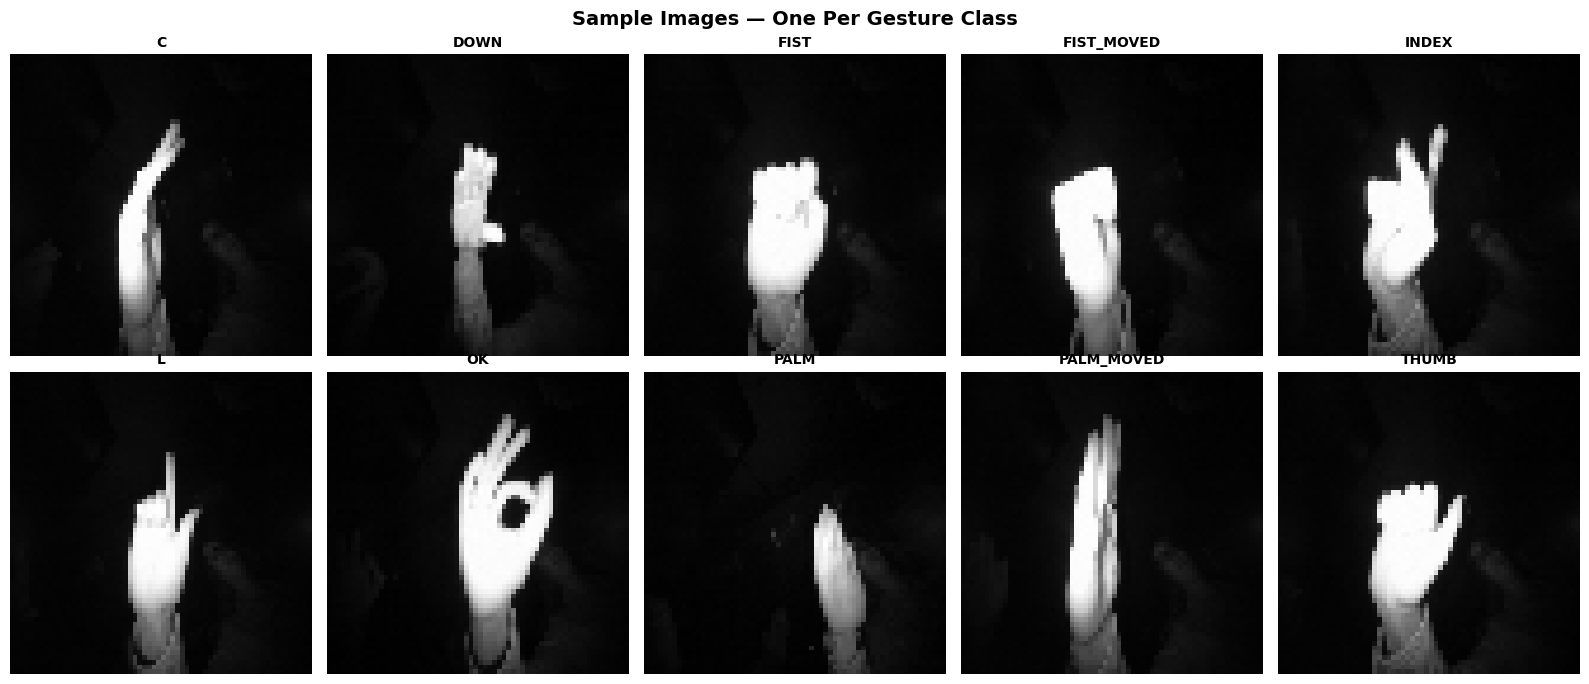

Total gesture classes: 10


In [7]:
unique_classes = sorted(np.unique(labels))
n_classes = len(unique_classes)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
fig.suptitle('Sample Images — One Per Gesture Class', fontsize=14, fontweight='bold')

for i, cls in enumerate(unique_classes):
    idx = np.where(labels == cls)[0][0]
    axes[i].imshow(images[idx], cmap='gray')
    axes[i].set_title(cls.upper(), fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_gestures.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total gesture classes: {n_classes}')

---
## Step 6 — Feature Extraction (HOG)

We extract **HOG (Histogram of Oriented Gradients)** features from each image.

HOG captures the shape and edge structure of hand gestures — perfect for distinguishing between different hand poses.

> ⏳ This may take 2-3 minutes for large datasets.

In [8]:
def extract_hog_features(img):
    """Extract HOG features from a grayscale image."""
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False
    )
    return features

print('Extracting HOG features... please wait...')
X = np.array([extract_hog_features(img) for img in images])

# Encode string labels to integers
le = LabelEncoder()
y  = le.fit_transform(labels)

print(f'\n✅ Feature extraction done!')
print(f'Feature matrix shape : {X.shape}')
print(f'Each image → {X.shape[1]} HOG features')
print(f'Classes              : {list(le.classes_)}')

Extracting HOG features... please wait...

✅ Feature extraction done!
Feature matrix shape : (2000, 1764)
Each image → 1764 HOG features
Classes              : ['c', 'down', 'fist', 'fist_moved', 'index', 'l', 'ok', 'palm', 'palm_moved', 'thumb']


---
## Step 7 — Train/Test Split & Feature Scaling

Split data 80/20 and scale features using StandardScaler.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

# Scale features
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size : {X_train.shape[0]} images')
print(f'Test  size : {X_test.shape[0]} images')
print('✅ Feature scaling done!')

Train size : 1600 images
Test  size : 400 images
✅ Feature scaling done!


---
## Step 8 — Train Random Forest Model

**Random Forest** is an ensemble of decision trees — fast and effective for multi-class problems.

- `n_estimators=100` — 100 decision trees
- `random_state=42` — reproducibility

In [10]:
print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_SEED,
    n_jobs=-1    # use all CPU cores
)
rf_model.fit(X_train, y_train)   # RF doesn't need scaled features

rf_pred     = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f'✅ Random Forest Accuracy : {rf_accuracy * 100:.2f}%')

Training Random Forest...
✅ Random Forest Accuracy : 99.75%


---
## Step 9 — Train SVM Model

**SVM with RBF kernel** — powerful for high-dimensional HOG features.

> ⏳ SVM training will take 2-5 minutes.

In [11]:
print('Training SVM... please wait...')

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=RANDOM_SEED
)
svm_model.fit(X_train_sc, y_train)

svm_pred     = svm_model.predict(X_test_sc)
svm_accuracy = accuracy_score(y_test, svm_pred)

print(f'✅ SVM Accuracy : {svm_accuracy * 100:.2f}%')

Training SVM... please wait...
✅ SVM Accuracy : 100.00%


---
## Step 10 — Compare Both Models

In [12]:
print('=' * 45)
print(f'  Random Forest Accuracy : {rf_accuracy  * 100:.2f}%')
print(f'  SVM Accuracy           : {svm_accuracy * 100:.2f}%')
print('=' * 45)

# Use the better model for further evaluation
if svm_accuracy >= rf_accuracy:
    best_pred  = svm_pred
    best_name  = 'SVM'
    best_acc   = svm_accuracy
else:
    best_pred  = rf_pred
    best_name  = 'Random Forest'
    best_acc   = rf_accuracy

print(f'\n🏆 Best Model: {best_name} ({best_acc*100:.2f}%)')

  Random Forest Accuracy : 99.75%
  SVM Accuracy           : 100.00%

🏆 Best Model: SVM (100.00%)


---
## Step 11 — Classification Report (Best Model)

In [13]:
print(f'Classification Report — {best_name}:')
print(classification_report(
    y_test, best_pred,
    target_names=le.classes_
))

Classification Report — SVM:
              precision    recall  f1-score   support

           c       1.00      1.00      1.00        40
        down       1.00      1.00      1.00        40
        fist       1.00      1.00      1.00        40
  fist_moved       1.00      1.00      1.00        40
       index       1.00      1.00      1.00        40
           l       1.00      1.00      1.00        40
          ok       1.00      1.00      1.00        40
        palm       1.00      1.00      1.00        40
  palm_moved       1.00      1.00      1.00        40
       thumb       1.00      1.00      1.00        40

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



---
## Step 12 — Confusion Matrix

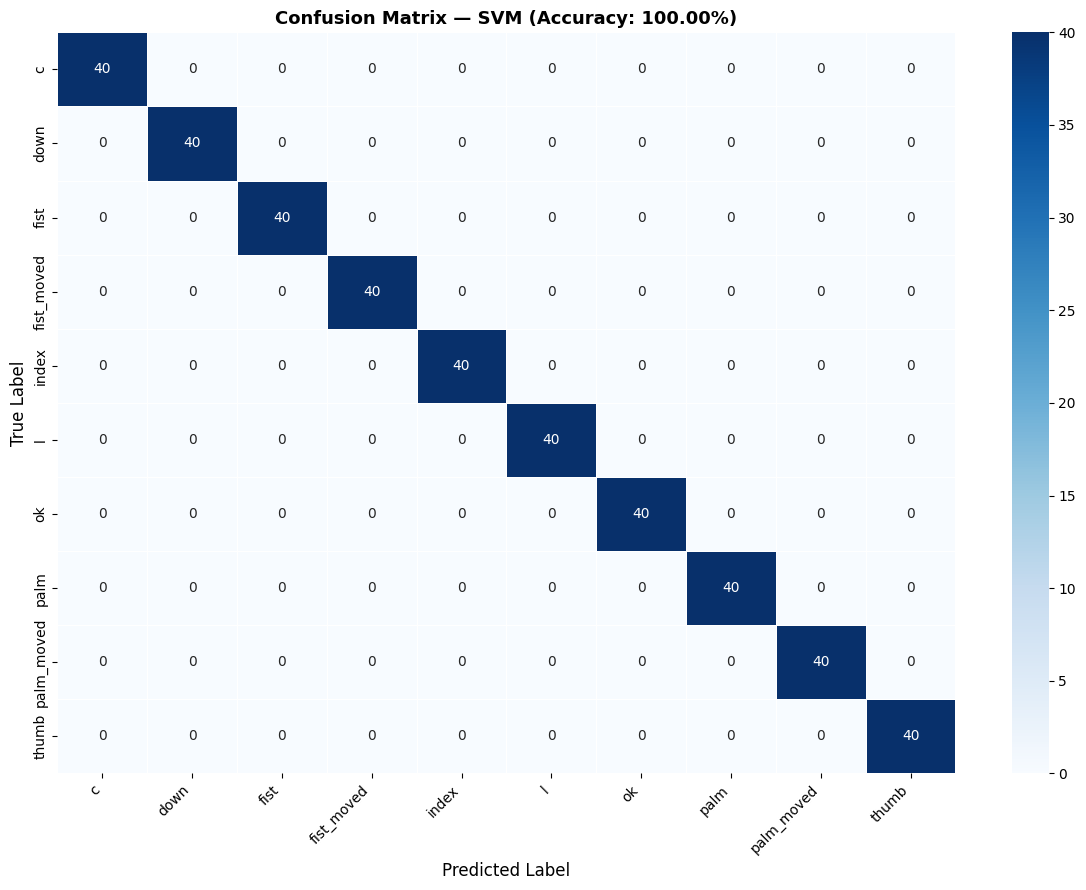

In [14]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix — {best_name} (Accuracy: {best_acc*100:.2f}%)',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 13 — Model Accuracy Comparison Chart

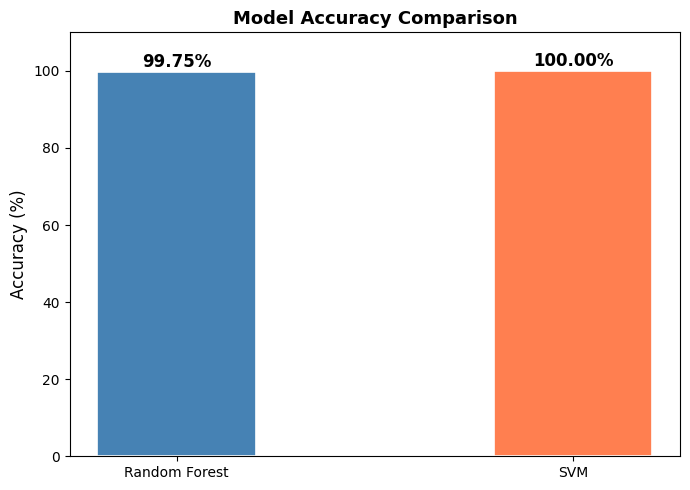

In [15]:
models     = ['Random Forest', 'SVM']
accuracies = [rf_accuracy * 100, svm_accuracy * 100]
colors     = ['steelblue', 'coral']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='white', linewidth=1.2, width=0.4)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(0, 110)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 14 — Visualise Predictions

Show 10 sample test images with true vs predicted labels.
- ✅ **Green** = correct prediction
- ❌ **Red** = wrong prediction

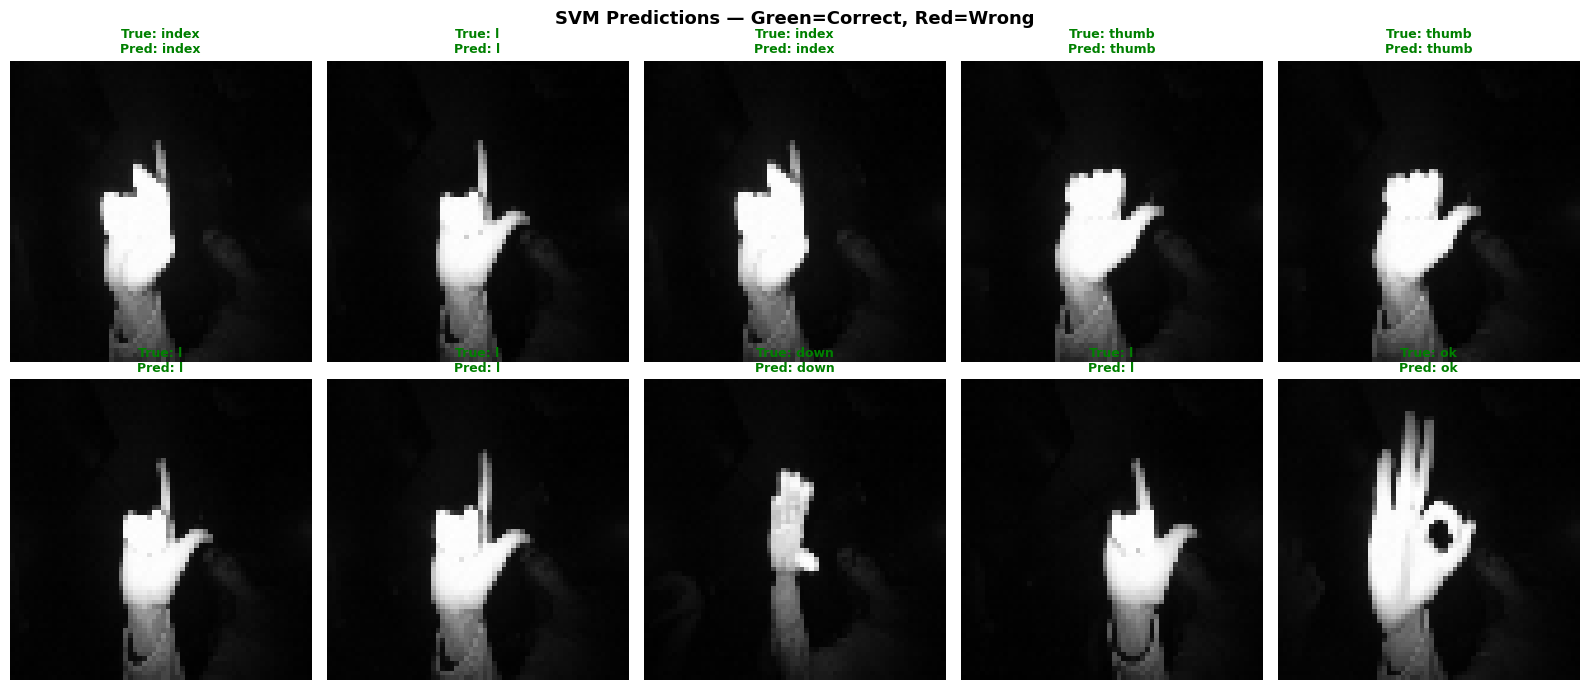

In [16]:
all_indices = np.arange(len(images))
_, test_indices = train_test_split(
    all_indices, test_size=0.2,
    random_state=RANDOM_SEED, stratify=y
)

n_show     = 10
sample_idx = np.random.choice(len(test_indices), n_show, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
fig.suptitle(f'{best_name} Predictions — Green=Correct, Red=Wrong',
             fontsize=13, fontweight='bold')

for i, s_idx in enumerate(sample_idx):
    orig_idx   = test_indices[s_idx]
    true_label = le.classes_[y_test[s_idx]]
    pred_label = le.classes_[best_pred[s_idx]]
    correct    = true_label == pred_label

    axes[i].imshow(images[orig_idx], cmap='gray')
    axes[i].set_title(
        f'True: {true_label}\nPred: {pred_label}',
        color='green' if correct else 'red',
        fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 15 — Predict on a Single Custom Image

Update `IMAGE_PATH` to test on any hand gesture image.

In [17]:
def predict_gesture(image_path, model='svm'):
    """
    Predict gesture from a single image.
    model: 'svm' or 'rf'
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f'Could not read: {image_path}')
        return

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    features    = extract_hog_features(img_resized).reshape(1, -1)

    if model == 'svm':
        features_sc = scaler.transform(features)
        pred        = svm_model.predict(features_sc)[0]
    else:
        pred = rf_model.predict(features)[0]

    gesture = le.classes_[pred]

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f'Predicted Gesture: {gesture.upper()}',
              fontsize=12, fontweight='bold', color='green')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'Predicted Gesture: {gesture.upper()}')


# ── UPDATE PATH to test on your own image ──
# predict_gesture('path/to/gesture_image.png', model='svm')

---
## ✅ Summary

| Item | Detail |
|------|--------|
| Dataset | LeapGestRecog (Leap Motion) |
| Total Classes | 10 hand gestures |
| Feature Extraction | HOG (Histogram of Oriented Gradients) |
| Models Trained | Random Forest + SVM (RBF kernel) |
| Image Size | 64×64 grayscale |

### 10 Gesture Classes
| Gesture | Description |
|---------|-------------|
| palm | Open palm facing camera |
| l | L-shape with thumb and index |
| fist | Closed fist |
| fist_moved | Fist in motion |
| thumb | Thumbs up |
| index | Index finger pointing |
| ok | OK sign |
| palm_moved | Palm in motion |
| c | C-shape hand |
| down | Hand pointing down |

### 💡 Tips to Improve Accuracy
- Increase `MAX_IMAGES` to use full dataset (2000 per class)
- Try `IMG_SIZE = 128` for richer HOG features
- Apply OTSU binarization before feature extraction
- Use PCA for dimensionality reduction before SVM
- For best results, use a CNN (deep learning) model